# Lecture 09, Notebook 11: Continuum-of-agents DEQN (Bewley endowment economy)

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §6.4 (DEQN with a continuum of agents)  
**Notebook role:** core  
**Author:** Simon Scheidegger  

---

In [1]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Solving the Continuum-of-Agents Model with Deep Equilibrium Nets

**Notebook 11** — Bewley Endowment Economy with Heterogeneous Agents

## Overview

We solve a **Bewley endowment economy** with a **continuum of agents**, aggregate and idiosyncratic shocks, **Epstein–Zin preferences**, and a **borrowing constraint**. The distribution of agents is tracked using **Young's (2010) non-stochastic histogram method**, which enters the neural network as a high-dimensional input.

### How this notebook fits the lecture
The lecture first uses the **Krusell-Smith benchmark** to explain why distribution tracking matters. This notebook is the **Appendix A.5 teaching implementation** from Azinovic, Gaegauf, and Scheidegger (2022). The common ingredient is Young's histogram update: the benchmark motivates **why** it matters, while this notebook shows **how** it enters a DEQN.

Two neural networks are trained jointly:
- A **policy network** $\mathcal{N}_{pol}$: maps individual + aggregate state $\to$ savings $b'$, KKT multiplier $\lambda$, value $V$
- A **price network** $\mathcal{N}_{price}$: maps aggregate state $\to$ bond price $p$

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 13
%matplotlib inline

print(f"TensorFlow version: {tf.__version__}")
print(f"Eager mode: {tf.executing_eagerly()}")

2026-05-12 13:49:54.793338: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-12 13:49:54.794061: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-12 13:49:54.798074: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-12 13:49:54.808504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778586594.825792   80974 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778586594.83

TensorFlow version: 2.19.0
Eager mode: True


## 1. Model Description

### Preferences
Each agent has **Epstein–Zin recursive utility** (separating risk aversion from IES):
$$V(x_t) = \max_{b_{t+1} \geq 0} \left[(1-\beta)\, c_t^{1-\rho} + \beta\, \chi_t\!\left(V(x_{t+1})\right)^{1-\rho}\right]^{\frac{1}{1-\rho}}$$

where $\chi_t(V_{t+1}) = \mathbb{E}_t\!\left[V_{t+1}^{1-\sigma}\right]^{\!\frac{1}{1-\sigma}}$ is the certainty equivalent.

| Parameter | Symbol | Value |
|-----------|--------|-------|
| Discount factor | $\beta$ | 0.95 |
| Inverse of IES | $\rho$ | 2 (IES = 0.5) |
| Risk aversion | $\sigma$ | 8 |

### Budget Constraint
$$c_t + p_t \cdot b_{t+1} = b_t + \eta_t \cdot w(a_t), \qquad b_{t+1} \geq 0$$

- $b_t$: bond holdings (asset), $p_t$: bond price (endogenous)
- $\eta_t \in \{0.8, 1.2\}$: idiosyncratic labor endowment
- $w(a_t) = Y(a_t) \in \{0.95, 1.0, 1.05\}$: aggregate output/wages

### Shock Structure
- **Aggregate shocks:** 6 states = 2 uncertainty regimes × 3 income levels
- **Idiosyncratic shocks:** $\eta \in \{0.8, 1.2\}$ with transition matrix $\Pi_\eta$

### Equilibrium Conditions
1. **Euler equation** (intertemporal optimality)
2. **Bellman equation** (value function consistency)
3. **Market clearing** $\int b_{t+1} \, d\mu_t = 1$ (bonds in unit net supply)
4. **KKT complementarity** $\lambda_t \cdot b_{t+1} = 0$
5. **Budget feasibility** $c_t > 0$

## 2. Parameters

In [3]:
# ============================================================
# Model parameters
# ============================================================
np.random.seed(SEED)
tf.random.set_seed(SEED)

nZ = 6       # Number of aggregate shock states
nEta = 2     # Number of idiosyncratic shock states
nUnc = 2     # Uncertainty regimes
nIn = 3      # Income levels

# Preferences (Epstein-Zin)
sigma = 8.0   # Risk aversion
rho = 2.0     # 1 / IES
beta = 0.95   # Discount factor

# RUN_MODE-driven hyperparameters.
# - smoke      : laptop CPU smoke run, full pipeline visible in class
# - teaching   : longer classroom run with the same architecture
# - production : paper-scale (Azinovic, Gaegauf & Scheidegger 2022, App. A.5)
_BUDGET = {
    "smoke":      {"nA":  50, "num_episodes":   100, "len_episodes":  256, "num_hidden": 128},
    "teaching":   {"nA":  50, "num_episodes":   500, "len_episodes":  256, "num_hidden": 128},
    "production": {"nA": 100, "num_episodes": 65000, "len_episodes": 2048, "num_hidden": 500},
}[RUN_MODE]

# Asset grid
nA = _BUDGET["nA"]
amin, amax = 0.0, 20.0
agrid = tf.linspace(amin, amax, nA)
deltaa = agrid[1] - agrid[0]

# Training hyperparameters
batch_size         = 128
num_episodes       = _BUDGET["num_episodes"]
len_episodes       = _BUDGET["len_episodes"]
epochs_per_episode = 1
num_tracks         = 16
num_id_per_shock   = 4
lr                 = 1e-5
save_interval      = 50
num_hidden         = _BUDGET["num_hidden"]

print(f"RUN_MODE={RUN_MODE}")
print(f"Asset grid: {nA} points on [{amin}, {amax}], delta = {deltaa:.4f}")
print(f"Training: {num_episodes} episodes, len_episodes={len_episodes}, batch={batch_size}, lr={lr}")
print(f"Network: {num_hidden} hidden units / layer")
print(f"Preferences: beta={beta}, rho={rho}, sigma={sigma}")


RUN_MODE=smoke
Asset grid: 50 points on [0.0, 20.0], delta = 0.4082
Training: 100 episodes, len_episodes=256, batch=128, lr=1e-05
Network: 128 hidden units / layer
Preferences: beta=0.95, rho=2.0, sigma=8.0


E0000 00:00:1778586600.085941   80974 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778586600.088429   80974 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### Current notebook defaults

The hyperparameters above are dispatched on the kit-mandated `RUN_MODE` constant from the second cell:

| `RUN_MODE`     | $N_b$ | hidden | episodes | len_episodes |
|----------------|-------|--------|----------|--------------|
| `smoke`        |  50   | 128    |    100   |   256        |
| `teaching`     |  50   | 128    |    500   |   256        |
| `production`   | 100   | 500    | 65 000   |  2048        |

The checked-in default is `smoke`, so the full pipeline is inspectable in class.  Bump to `teaching` for a fuller run that still finishes on a laptop, or to `production` for the paper-scale configuration of Azinovic, Gaegauf & Scheidegger (2022, Appendix A.5).


## 3. Shock Structure

The aggregate state has $2 \times 3 = 6$ values, combining 2 uncertainty regimes with 3 income levels. Transition probabilities are constructed as the Kronecker product of uncertainty and income transitions.

In [4]:
# ============================================================
# Aggregate shock transitions (6x6)
# ============================================================
pers_unc = np.array([
    [0.8, 0.2],
    [0.2, 0.8]
])

pers_in_normal = np.array([
    [0.70, 0.20, 0.10],
    [0.15, 0.70, 0.15],
    [0.10, 0.20, 0.70]
])

pers_in_high = np.array([
    [0.75, 0.10, 0.15],
    [0.20, 0.60, 0.20],
    [0.15, 0.10, 0.75]
])

# Build 6x6 transition matrix
pi_Z_np = np.empty((nZ, nZ))
pi_Z_np[0:nIn, 0:nIn] = pers_in_normal * pers_unc[0, 0]
pi_Z_np[0:nIn, nIn:2*nIn] = pers_in_normal * pers_unc[0, 1]
pi_Z_np[nIn:2*nIn, 0:nIn] = pers_in_high * pers_unc[1, 0]
pi_Z_np[nIn:2*nIn, nIn:2*nIn] = pers_in_high * pers_unc[1, 1]

pi_Z = tf.constant(pi_Z_np, dtype=tf.float32)

# Output/wages per aggregate state
Y_vec = tf.constant([[0.95], [1.00], [1.05], [0.95], [1.00], [1.05]], dtype=tf.float32)
wage_vec = Y_vec

# ============================================================
# Idiosyncratic shock transitions (2x2)
# ============================================================
pi_Eta = tf.constant([[0.7, 0.3], [0.3, 0.7]], dtype=tf.float32)
eta_vec = tf.constant([[0.8], [1.2]], dtype=tf.float32)

print("Aggregate transition matrix pi_Z (6x6):")
print(np.round(pi_Z_np, 3))
print(f"\nRow sums: {pi_Z_np.sum(axis=1)}")
print(f"\nIdiosyncratic transitions pi_Eta: {pi_Eta.numpy()}")
print(f"Idiosyncratic endowments eta: {eta_vec.numpy().flatten()}")
print(f"Output/wages Y: {Y_vec.numpy().flatten()}")

Aggregate transition matrix pi_Z (6x6):
[[0.56 0.16 0.08 0.14 0.04 0.02]
 [0.12 0.56 0.12 0.03 0.14 0.03]
 [0.08 0.16 0.56 0.02 0.04 0.14]
 [0.15 0.02 0.03 0.6  0.08 0.12]
 [0.04 0.12 0.04 0.16 0.48 0.16]
 [0.03 0.02 0.15 0.12 0.08 0.6 ]]

Row sums: [1. 1. 1. 1. 1. 1.]

Idiosyncratic transitions pi_Eta: [[0.7 0.3]
 [0.3 0.7]]
Idiosyncratic endowments eta: [0.8 1.2]
Output/wages Y: [0.95 1.   1.05 0.95 1.   1.05]


## 4. Asset Grid and State Vectors

The **individual state** is $(\eta_t, b_t)$ — 2 values.

The **aggregate state** is $(z_{\text{idx}}, \text{in}_{\text{idx}}, \text{unc}_{\text{idx}}, h^{\eta=0.8}, h^{\eta=1.2})$ — $3 + 2N_b$ values.

The policy network takes the full state: dimension $= 5 + 2N_b$.  
The price network takes only the aggregate state: dimension $= 3 + 2N_b$.

In [5]:
# ============================================================
# Build vector of all idiosyncratic states for histogram evaluation
# ============================================================
id_vec_np = np.zeros([2 * nA, 2])
id_vec_np[:nA, 0] = 0.0           # eta_idx = 0
id_vec_np[:nA, 1] = agrid.numpy() # b on grid
id_vec_np[nA:, 0] = 1.0           # eta_idx = 1
id_vec_np[nA:, 1] = agrid.numpy() # b on grid
id_vec = tf.constant(id_vec_np, dtype=tf.float32)

dim_policy_input = 5 + 2 * nA   # (eta_idx, b, z_idx, in_idx, unc_idx, h_eta0[nA], h_eta1[nA])
dim_price_input = 3 + 2 * nA    # (z_idx, in_idx, unc_idx, h_eta0[nA], h_eta1[nA])

print(f"Asset grid: {nA} points, delta = {deltaa:.4f}")
print(f"id_vec shape: {id_vec.shape} (all eta x b combinations)")
print(f"Policy network input dim: {dim_policy_input}")
print(f"Price network input dim: {dim_price_input}")

Asset grid: 50 points, delta = 0.4082
id_vec shape: (100, 2) (all eta x b combinations)
Policy network input dim: 105
Price network input dim: 103


## 5. Young's Method Functions

Young's (2010) **non-stochastic simulation** is implemented inside the
DEQN training loop. This is the same redistribution logic isolated in
`10_Youngs_Method_Examples.ipynb`, lifted to the full aggregate state
vector used by the DEQN.

##### What the lottery does

Given a fine asset grid $\{a_0, \dots, a_{N-1}\}$ and a household whose
next-period asset choice is $a' = \hat\pi(a, \eta)$ (typically falling
*between* two grid points $a_j \leq a' < a_{j+1}$), Young's lottery
splits the household's mass deterministically:

$$
\text{mass}(a_j) \mathrel{+}= \frac{a_{j+1} - a'}{a_{j+1} - a_j},
\qquad
\text{mass}(a_{j+1}) \mathrel{+}= \frac{a' - a_j}{a_{j+1} - a_j}.
$$

##### Why "non-stochastic" --- and why it matters here

- Each step is a **deterministic** finite linear operation on the
  histogram --- no Monte Carlo noise enters the simulation.
- Combined with a Markov transition over the idiosyncratic shock $\eta$,
  it gives an exact, finite-dimensional, **differentiable** evolution of
  the cross-sectional distribution. This is the property the DEQN
  exploits: the policy network's gradients can flow back through the
  histogram update.
- The cost is $\mathcal{O}(N)$ per step --- comparable to a single
  Monte Carlo path but without the variance.

Three key functions implement this:

1. `get_weights_grid()` --- linear interpolation weights for placing
   mass on the asset grid (the lottery formulae above).
2. `get_weights_eta()` --- full histogram update using the policy
   network and the $\pi_\eta$ transitions.
3. `get_Xagg_next()` --- constructs next-period aggregate states for
   all 6 possible aggregate-shock realisations.

In [6]:
# ============================================================
# Young's method: interpolation weights on the asset grid
# ============================================================
@tf.function(input_signature=[
    tf.TensorSpec(shape=(None, 1), dtype=tf.float32),
    tf.TensorSpec(shape=(nA,), dtype=tf.float32),
    tf.TensorSpec(shape=(), dtype=tf.float32)])
def get_weights_grid(asearch, agrid, deltaa):
    """Linear interpolation weights for Young's histogram update.
    
    For each value in asearch, compute weights on the asset grid
    such that the weighted sum preserves the mean exactly.
    """
    agrid_2 = tf.reshape(agrid, [1, -1])
    dif = tf.math.abs(agrid_2 - asearch)
    mask = tf.cast((dif < deltaa), dtype=tf.float32)
    w1 = 1.0 - (dif / deltaa)
    w1 = w1 * mask
    w1 = w1 / tf.math.reduce_sum(w1, axis=1, keepdims=True)
    return w1


# ============================================================
# Young's method: full histogram update
# ============================================================
@tf.function
def get_weights_eta(net, X_agg):
    """Update the histogram using the policy network and idiosyncratic transitions.
    
    For each (eta, b) on the grid:
      1. Evaluate policy net to get b' = net(eta, b, X_agg)
      2. Compute interpolation weights for b' on the grid
      3. Redistribute mass according to pi_Eta transitions
    """
    nAgg = X_agg.shape[0]
    
    # Construct full state for all (eta, b) on grid
    X_agg_rep = tf.repeat(X_agg, nEta * nA * tf.ones(nAgg, dtype=tf.int32), axis=0)
    X_id_rep = tf.tile(id_vec, [nAgg, 1])
    X = tf.concat([X_id_rep, X_agg_rep], axis=1)
    
    # Get savings policy b' for all grid points
    anext = net(X)[:, 0:1]
    anext = tf.minimum(anext, amax * tf.ones_like(anext))  # clip at grid boundary
    
    # Get interpolation weights
    assoc_weightsnext = get_weights_grid(anext, agrid, deltaa)
    assoc_weightsnext = tf.reshape(assoc_weightsnext, [nAgg, nEta * nA, nA])
    
    # Redistribute mass across eta' states
    new_weights_list = []
    for etaidx in range(nEta):
        from_list = []
        weight_old = tf.expand_dims(X_agg[:, 3 + etaidx * nA : 3 + (etaidx + 1) * nA], -1)
        temp_weights_new = assoc_weightsnext[:, etaidx * nA : (etaidx + 1) * nA, :]
        for etanidx in range(nEta):
            trans_prob = pi_Eta[etaidx, etanidx]
            weight_etatransition = trans_prob * tf.math.reduce_sum(weight_old * temp_weights_new, axis=1)
            from_list.append(weight_etatransition)
        new_weights_list.append(from_list)
    
    new_weights = tf.concat([sum(x) for x in zip(*new_weights_list)], axis=1)
    
    # Normalize to preserve mass per eta type (each should sum to 0.5)
    sum_id0 = tf.reduce_sum(new_weights[:, 0:nA], axis=1, keepdims=True)
    sum_id1 = tf.reduce_sum(new_weights[:, nA:2*nA], axis=1, keepdims=True)
    
    new_weights = tf.concat([
        0.5 * (new_weights[:, 0:nA] / sum_id0),
        0.5 * (new_weights[:, nA:2*nA] / sum_id1)
    ], axis=1)
    
    return new_weights


# ============================================================
# Construct next-period aggregate states for all 6 shocks
# ============================================================
@tf.function
def get_Xagg_next(net, X_agg):
    """Given current aggregate state, compute next-period aggregate
    states for each of the 6 possible aggregate shock realizations.
    The histogram is updated via Young's method."""
    nAgg = X_agg.shape[0]
    
    # Shock indices for each of the 6 states
    # States 0-2: low uncertainty (unc=0), income levels 0,1,2
    # States 3-5: high uncertainty (unc=1), income levels 0,1,2
    z_indices = [0., 1., 2., 3., 4., 5.]
    in_indices = [0., 1., 2., 0., 1., 2.]
    unc_indices = [0., 0., 0., 1., 1., 1.]
    
    # Update histogram using current policy
    weightsnext = get_weights_eta(net, X_agg)
    
    # Build next-period aggregate states
    results = []
    for i in range(nZ):
        zidx = z_indices[i] * tf.ones([nAgg, 1])
        inidx = in_indices[i] * tf.ones([nAgg, 1])
        uncidx = unc_indices[i] * tf.ones([nAgg, 1])
        results.append(tf.concat([zidx, inidx, uncidx, weightsnext], axis=1))
    
    return results[0], results[1], results[2], results[3], results[4], results[5]

print("Young's method functions defined.")

Young's method functions defined.


## 5b. Bridge: One DEQN-Style Histogram Update

Before training the networks, it helps to run one synthetic forward step with the **actual aggregate state vector** used in this notebook:

- the first 3 entries are shock indices
- the remaining $2N_b$ entries are the histogram blocks
- `get_weights_eta()` is notebook 10's redistribution operator embedded in this larger state object

In [7]:
# Demo aggregate state: one shock state, equal mass at the same asset bin for both eta blocks
Xagg_demo = np.zeros((1, 3 + 2 * nA), dtype=np.float32)
demo_idx = 4
Xagg_demo[0, 3 + demo_idx] = 0.5
Xagg_demo[0, 3 + nA + demo_idx] = 0.5
Xagg_demo = tf.constant(Xagg_demo)

class MockPolicyNet(tf.keras.Model):
    def call(self, X):
        eta_idx = X[:, 0:1]
        b = X[:, 1:2]
        eta = tf.where(eta_idx < 0.5, 0.8, 1.2)
        b_next = tf.clip_by_value(0.85 * b + 0.15 * eta, amin, amax)
        lambd = 1e-3 * tf.ones_like(b_next)
        V = 1.0 + 0.05 * b_next
        return tf.concat([b_next, lambd, V], axis=1)

mock_net = MockPolicyNet()
h_demo_next = get_weights_eta(mock_net, Xagg_demo)

X_demo_full = tf.concat([id_vec, tf.repeat(Xagg_demo, nEta * nA, axis=0)], axis=1)
bprime_demo = mock_net(X_demo_full)[:, 0]
h_demo = Xagg_demo.numpy()[0, 3:]
agg_bprime = np.dot(h_demo, bprime_demo.numpy())

print(f"Current mass: {Xagg_demo.numpy()[0, 3:].sum():.6f}")
print(f"Next mass:    {h_demo_next.numpy()[0].sum():.6f}")
print(f"Eta-block masses: {h_demo_next.numpy()[0, :nA].sum():.3f}, {h_demo_next.numpy()[0, nA:].sum():.3f}")
print(f"Histogram dot product h · b': {agg_bprime:.6f}")


Current mass: 1.000000
Next mass:    1.000000
Eta-block masses: 0.500, 0.500
Histogram dot product h · b': 1.537755


## 6. Neural Network Architecture

Two networks, trained jointly:

| Network | Input | Hidden layers | Output | Activation |
|---------|-------|---------------|--------|------------|
| Policy $\mathcal{N}_{pol}$ | $5 + 2N_b$ | 2 × 128 (ReLU) | 3 | Softplus |
| Price $\mathcal{N}_{price}$ | $3 + 2N_b$ | 2 × 128 (ReLU) | 1 | Softplus |

- Policy outputs: $(b', \lambda, V)$ — all strictly positive via softplus
- Price output: bond price $p$ — strictly positive

> **Note:** The original paper uses 500 hidden nodes. We use 128 for faster classroom demos.

In [8]:
# ============================================================
# Policy network: (eta_idx, b, X_agg) -> (b', lambda, V)
# ============================================================
inputs_pol = keras.Input(shape=(dim_policy_input,))
x = keras.layers.Dense(num_hidden, activation='relu')(inputs_pol)
x = keras.layers.Dense(num_hidden, activation='relu')(x)
outputs_pol = keras.layers.Dense(3, activation='softplus')(x)
net_pol = keras.Model(inputs=inputs_pol, outputs=outputs_pol)

# ============================================================
# Price network: X_agg -> p
# ============================================================
inputs_price = keras.Input(shape=(dim_price_input,))
x = keras.layers.Dense(num_hidden, activation='relu')(inputs_price)
x = keras.layers.Dense(num_hidden, activation='relu')(x)
outputs_price = keras.layers.Dense(1, activation='softplus')(x)
net_price = keras.Model(inputs=inputs_price, outputs=outputs_price)

print("=== Policy Network ===")
net_pol.summary()
print("\n=== Price Network ===")
net_price.summary()

=== Policy Network ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 105)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        13,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,467 (119.01 KB)

 Trainable params: 30,467 (119.01 KB)

...

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 103)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        13,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,953 (117.00 KB)

 Trainable params: 29,953 (117.00 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Model Equations

### Budget constraint
$$c = b + \eta \cdot w(a) - p \cdot b'$$

### Epstein–Zin recursion
The certainty equivalent and Euler expectation involve summing over all $6 \times 2 = 12$ possible next-period shock combinations $(a', \eta')$:

$$\chi = \left(\sum_{(a',\eta')} \pi_{a'|a} \cdot \pi_{\eta'|\eta} \cdot V_{t+1}^{1-\sigma}\right)^{\!\frac{1}{1-\sigma}}$$

$$\text{Euler exp.} = \sum_{(a',\eta')} \pi_{a'|a} \cdot \pi_{\eta'|\eta} \cdot c_{t+1}^{-\rho} \cdot \left(\frac{V_{t+1}}{\chi}\right)^{\!\rho - \sigma}$$

In [9]:
# ============================================================
# Helper: extract wage from aggregate state
# ============================================================
@tf.function(input_signature=[tf.TensorSpec(shape=(None, 3 + 2 * nA), dtype=tf.float32)])
def get_zidxwage(X_agg):
    zidx = tf.cast(X_agg[:, 0:1], tf.int32)
    wage = tf.gather(wage_vec, zidx[:, 0])
    return zidx, wage

print("Helper functions defined.")

Helper functions defined.


## 8. Cost Function

The loss function evaluates **five equilibrium conditions** simultaneously:

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \left[\text{EE}_i^2 + \text{BE}_i^2 + n_Z \cdot \text{MC}_i^2 + \text{KKT}_i^2 + \text{CB}_i^2\right]$$

For each sample point, the function:
1. Evaluates both networks at the current state
2. Computes consumption from the budget constraint
3. For each of 12 next-period (aggregate × idiosyncratic) states: evaluates next-period policies and prices
4. Computes the certainty equivalent $\chi$ and Euler expectation
5. Forms all five residuals

In [10]:
# ============================================================
# Cost function
# ============================================================
@tf.function
def cost(net_pol, net_price, X, Xaggnext0, Xaggnext1, Xaggnext2,
         Xaggnext3, Xaggnext4, Xaggnext5):
    eps = 1e-6
    nSamples = X.shape[0]
    
    # === Read out the state ===
    etaidx = tf.cast(X[:, 0:1], tf.int32)
    eta = tf.gather(eta_vec, etaidx[:, 0])
    a = X[:, 1:2]
    X_agg = X[:, 2:]
    
    # Aggregate quantities today
    zidx, wage = get_zidxwage(X_agg)
    p = net_price(X_agg)
    
    # Policy predictions today
    prediction = net_pol(X)
    anext = prediction[:, 0:1]    # b'
    lambd = prediction[:, 1:2]    # KKT multiplier
    V = prediction[:, 2:3]        # Value function
    
    # Consumption from budget constraint
    c_try = a + eta * wage - anext * p
    c = tf.maximum(c_try, eps * tf.ones_like(c_try))
    
    # === Next-period states ===
    Xaggnexts = [Xaggnext0, Xaggnext1, Xaggnext2, Xaggnext3, Xaggnext4, Xaggnext5]
    
    # Get wages and prices for each aggregate shock
    wagenexts = []
    pnexts = []
    for i in range(nZ):
        _, wn = get_zidxwage(Xaggnexts[i])
        wagenexts.append(wn)
        pnexts.append(net_price(Xaggnexts[i]))
    
    # Idiosyncratic next-period states
    etanext_vals = [eta_vec[0, 0], eta_vec[1, 0]]
    Xidnexts = [
        tf.concat([0.0 * tf.ones([nSamples, 1]), anext], axis=1),  # eta=0
        tf.concat([1.0 * tf.ones([nSamples, 1]), anext], axis=1),  # eta=1
    ]
    
    # Evaluate policy net for all 12 next-period states
    Vnexts = {}   # (agg_idx, id_idx) -> V'
    cnexts = {}   # (agg_idx, id_idx) -> c'
    cnexts_try = {}  # for punishment term
    
    for ai in range(nZ):
        for ii in range(nEta):
            Xnext = tf.concat([Xidnexts[ii], Xaggnexts[ai]], axis=1)
            pred_next = net_pol(Xnext)
            anextnext = pred_next[:, 0:1]
            Vnexts[(ai, ii)] = pred_next[:, 2:3]
            
            cn_try = anext + etanext_vals[ii] * wagenexts[ai] - anextnext * pnexts[ai]
            cnexts_try[(ai, ii)] = cn_try
            cnexts[(ai, ii)] = tf.maximum(cn_try, eps * tf.ones_like(cn_try))
    
    # === Transition probabilities ===
    idnext0 = tf.gather(pi_Eta, etaidx[:, 0])[:, 0:1]
    idnext1 = tf.gather(pi_Eta, etaidx[:, 0])[:, 1:2]
    
    aggnexts = []
    for i in range(nZ):
        aggnexts.append(tf.gather(pi_Z, zidx[:, 0])[:, i:i+1])
    
    # Joint transition probabilities
    trans = {}
    for ai in range(nZ):
        for ii in range(nEta):
            id_prob = idnext0 if ii == 0 else idnext1
            trans[(ai, ii)] = aggnexts[ai] * id_prob
    
    # === Certainty equivalent ===
    mu = tf.zeros_like(V)
    for ai in range(nZ):
        for ii in range(nEta):
            mu = mu + trans[(ai, ii)] * Vnexts[(ai, ii)] ** (1.0 - sigma)
    mu = mu ** (1.0 / (1.0 - sigma))
    
    # === Euler expectation ===
    exp_euler = tf.zeros_like(V)
    for ai in range(nZ):
        for ii in range(nEta):
            exp_euler = exp_euler + (
                trans[(ai, ii)] 
                * cnexts[(ai, ii)] ** (-rho) 
                * (Vnexts[(ai, ii)] / mu) ** (rho - sigma)
            )
    
    # === Relative Euler equation error ===
    releue = ((beta * exp_euler + lambd) / p) ** (-1.0 / rho) / c - 1.0
    
    # === Relative Bellman equation error ===
    Vopt = ((1.0 - beta) * c ** (1.0 - rho) + beta * mu ** (1.0 - rho)) ** (1.0 / (1.0 - rho))
    relbee = (Vopt / V) - 1.0
    
    # === KKT complementarity error ===
    KKTerr = anext * lambd
    
    # === Budget feasibility penalty ===
    punish = tf.math.abs(c_try - c)
    for ai in range(nZ):
        for ii in range(nEta):
            punish = punish + tf.math.abs(cnexts[(ai, ii)] - cnexts_try[(ai, ii)])
    punish = punish * 100.0
    
    # === Market clearing via histogram ===
    weights_next = get_weights_eta(net_pol, X_agg)
    aggdem = tf.math.reduce_sum(
        weights_next * tf.tile(tf.reshape(agrid, [1, nA]), [1, 2]),
        axis=1, keepdims=True
    )
    mcerr = tf.math.abs(aggdem - 1.0) * nZ
    
    # === Total cost ===
    error = tf.concat([releue, relbee, mcerr, KKTerr, punish], axis=1)
    total_cost = tf.math.reduce_sum(error ** 2) / nSamples
    
    return total_cost, c, releue, relbee, exp_euler, lambd, mu, mcerr, KKTerr

print("Cost function defined.")

Cost function defined.


## 9. Training Data Generation

Training is **episode-based**:
1. Simulate a sequence of aggregate shocks via the Markov chain
2. Propagate the histogram forward using Young's method + current policy network
3. At each time step, sample random idiosyncratic states $(b, \eta)$
4. Combine into training batches

In [11]:
# ============================================================
# Simulate aggregate shock sequences
# ============================================================
def sim_shocks(z0idx, T):
    """Simulate aggregate shock indices via Markov chain."""
    ntracks = z0idx.shape[0]
    rands = np.random.rand(ntracks, T)
    zidx_evol = np.empty((ntracks, T), np.int32)
    zidx_evol[:, 0:1] = z0idx
    
    for i in range(ntracks):
        for t in range(1, T):
            zoldidx = zidx_evol[i, t - 1]
            rand = rands[i, t - 1]
            agg_trans = 0.0
            for znidx in range(nZ):
                agg_trans += pi_Z_np[int(zoldidx), int(znidx)]
                if rand <= agg_trans:
                    zidx_evol[i, t] = znidx
                    break
    return zidx_evol


# ============================================================
# Generate sequence of aggregate states with histogram evolution
# ============================================================
def get_sequence_agg(zidx_evol, Xagg_0, net):
    """Propagate histogram forward for T periods."""
    nAgg = Xagg_0.shape[0]
    T = zidx_evol.shape[1]
    
    Xagg_evol = [Xagg_0]
    Xaggnext_evols = [[] for _ in range(nZ)]
    
    for t in range(T):
        Xagg = Xagg_evol[-1]
        Xaggnexts = get_Xagg_next(net, Xagg)
        for i in range(nZ):
            Xaggnext_evols[i].append(Xaggnexts[i])
        
        if t < T - 1:
            zidxnext = zidx_evol[:, t + 1]
            # Select the realized next-period state
            Xagg_new = tf.zeros_like(Xagg)
            for si in range(nZ):
                mask = tf.reshape(tf.cast(zidxnext == si, tf.float32), [-1, 1])
                Xagg_new = Xagg_new + mask * Xaggnexts[si]
            Xagg_evol.append(Xagg_new)
    
    Xagg_evol = tf.reshape(tf.concat(Xagg_evol, axis=0), [T * nAgg, -1])
    result = [Xagg_evol]
    for i in range(nZ):
        result.append(tf.reshape(tf.concat(Xaggnext_evols[i], axis=0), [T * nAgg, -1]))
    return result


# ============================================================
# Create training data for one episode
# ============================================================
def create_training_data(N_agg, N_id_per_shock, Xagg_0, net):
    """Generate one episode of training data."""
    ntracks = Xagg_0.shape[0]
    z0idx = Xagg_0[:, 0:1]
    nTagg = int(N_agg / ntracks)
    
    # Simulate aggregate shocks
    zidx_evol = sim_shocks(z0idx, nTagg)
    
    # Get aggregate state sequence with histogram evolution
    result = get_sequence_agg(tf.cast(zidx_evol, tf.float32), Xagg_0, net)
    Xagg_evol = result[0]
    Xaggnext_evols = result[1:]
    
    # Tile for idiosyncratic states
    Xagg_evol_tiled = tf.tile(Xagg_evol, [nEta * N_id_per_shock, 1])
    Xaggnext_data = [tf.tile(Xaggnext_evols[i], [nEta * N_id_per_shock, 1]) for i in range(nZ)]
    
    # Random idiosyncratic states
    n_total = nEta * N_id_per_shock * ntracks * nTagg
    a = tf.random.uniform((n_total, 1)) * (amax - amin) + amin
    etaidx = tf.cast(tf.random.uniform((n_total, 1)) < 0.5, tf.float32)
    
    X_data = tf.concat([etaidx, a, Xagg_evol_tiled], axis=1)
    
    return [X_data] + Xaggnext_data + [Xagg_evol]


# ============================================================
# Create tf.data.Dataset from training data
# ============================================================
def create_tfdata(data_list, buffer_size, batch_size):
    """Convert training data to shuffled, batched tf.data.Dataset."""
    # data_list: [X, Xaggnext0, ..., Xaggnext5]
    train_dataset = tf.data.Dataset.from_tensor_slices(tuple(data_list[:7]))
    train_dataset = train_dataset.shuffle(buffer_size=buffer_size).batch(batch_size)
    return train_dataset

print("Training data functions defined.")

Training data functions defined.


## 10. Training Loop

The training procedure:
1. For each episode: simulate aggregate shocks, propagate histogram via Young's method
2. Sample random idiosyncratic states, form training batch
3. Compute loss via the cost function, backpropagate through both networks
4. Update weights with Adam optimizer ($\alpha = 10^{-5}$)
5. Carry forward the end-of-episode histogram as the starting point for the next episode

In [12]:
# ============================================================
# Optimizer and training step
# ============================================================
optimizer_joint = keras.optimizers.Adam(learning_rate=lr)
joined_parameters = net_pol.trainable_weights + net_price.trainable_weights

@tf.function
def train_step(net_pol, net_price, optimizer, Xdata,
               Xaggnextdata0, Xaggnextdata1, Xaggnextdata2,
               Xaggnextdata3, Xaggnextdata4, Xaggnextdata5):
    with tf.GradientTape() as tape:
        loss_value = cost(net_pol, net_price, Xdata,
                          Xaggnextdata0, Xaggnextdata1, Xaggnextdata2,
                          Xaggnextdata3, Xaggnextdata4, Xaggnextdata5)[0]
    grads = tape.gradient(loss_value, joined_parameters)
    optimizer.apply_gradients(zip(grads, joined_parameters))
    return loss_value

print("Optimizer and train_step defined.")

Optimizer and train_step defined.


In [13]:
# ============================================================
# Training loop
# ============================================================
buffer_size = len_episodes * num_id_per_shock * nEta
num_batches = buffer_size / batch_size

loss_history = []

# Initialize starting points: equal mass for each eta type at the same grid point
Xagg_0 = np.zeros([num_tracks, nEta * nA + 3], dtype=np.float32)
# Place all mass at 4th grid point for each eta type
start_idx = 4
Xagg_0[:, 3 + start_idx] = 0.5
Xagg_0[:, 3 + nA + start_idx] = 0.5
Xagg_0 = tf.constant(Xagg_0, dtype=tf.float32)

# Checkpoint support
ckpt = tf.train.Checkpoint(
    optimizer_joint=optimizer_joint,
    policy=net_pol, price=net_price
)

print(f"Starting training: {num_episodes} episodes")
print(f"Buffer size: {buffer_size}, batches per episode: {num_batches:.0f}")
print("="*60)

for outer in range(num_episodes):
    episode_loss = 0.0
    
    # Generate training data for this episode
    data = create_training_data(len_episodes, num_id_per_shock, Xagg_0, net_pol)
    X_data = data[0]
    Xaggnext_data = data[1:7]
    Xagg_evol = data[7]
    
    # Create batched dataset
    train_dataset = create_tfdata(data, buffer_size, batch_size)
    
    # Update starting points from end of simulation
    Xagg_0 = Xagg_evol[-num_tracks:, :].numpy()
    
    # Train for one epoch
    for step, x_batch in enumerate(train_dataset):
        batch_loss = train_step(
            net_pol, net_price, optimizer_joint,
            x_batch[0], x_batch[1], x_batch[2],
            x_batch[3], x_batch[4], x_batch[5], x_batch[6]
        )
        episode_loss += batch_loss / num_batches
    
    loss_history.append(episode_loss.numpy())
    
    if outer % 50 == 0:
        print(f"Episode {outer:5d} | Loss [log10] = {np.log10(episode_loss.numpy()):8.3f}")

print("="*60)
print(f"Training complete. Final loss: {loss_history[-1]:.4e}")

Starting training: 100 episodes
Buffer size: 2048, batches per episode: 16


2026-05-12 13:50:06.585858: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Episode     0 | Loss [log10] =    0.881


2026-05-12 13:50:07.033323: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-05-12 13:50:07.861760: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

2026-05-12 13:50:12.739539: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-05-12 13:50:19.340798: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Episode    50 | Loss [log10] =    0.110


2026-05-12 13:50:32.372492: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Training complete. Final loss: 7.3951e-01


## 11. Loss Convergence

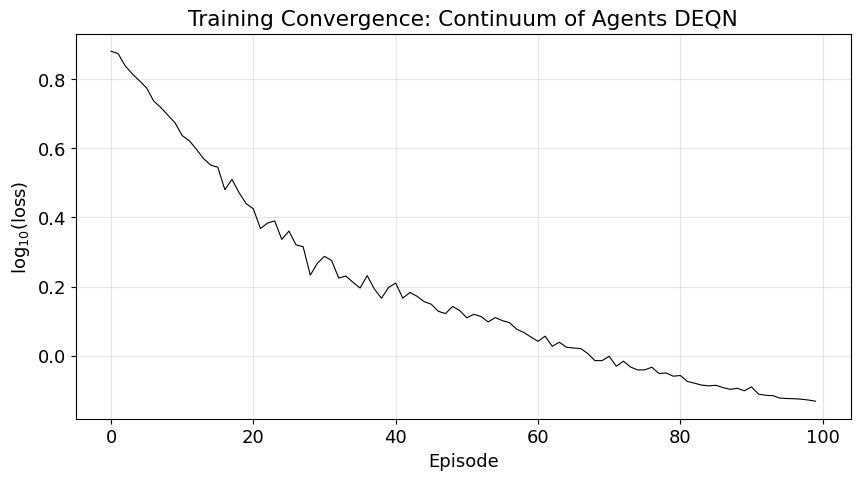

Initial loss: 7.60e+00
Final loss:   7.40e-01
Improvement:  10.3x


In [14]:
plt.figure(figsize=(10, 5))
plt.plot(np.log10(np.array(loss_history)), 'k-', linewidth=0.8)
plt.xlabel('Episode')
plt.ylabel('log$_{10}$(loss)')
plt.title('Training Convergence: Continuum of Agents DEQN')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial loss: {loss_history[0]:.2e}")
print(f"Final loss:   {loss_history[-1]:.2e}")
print(f"Improvement:  {loss_history[0]/loss_history[-1]:.1f}x")

## 12. Policy Functions

We evaluate the trained networks on a dense grid of asset holdings to visualize the learned policies.

In [15]:
# ============================================================
# Generate evaluation data on a dense asset grid
# ============================================================
# Use the last aggregate state from training
Xagg_eval = Xagg_0[-1:, :]  # shape (1, 3 + 2*nA)
Xagg_eval_tf = tf.constant(Xagg_eval, dtype=tf.float32)

N_plot = 200
a_plot = np.linspace(amin, amax, N_plot)

# Evaluate for eta=0.8 and eta=1.2
results_eta = {}
for eta_idx in range(nEta):
    # Build input: (eta_idx, b, X_agg)
    eta_col = eta_idx * np.ones((N_plot, 1), dtype=np.float32)
    a_col = a_plot.reshape(-1, 1).astype(np.float32)
    Xagg_tiled = np.tile(Xagg_eval, (N_plot, 1))
    X_eval = tf.constant(np.hstack([eta_col, a_col, Xagg_tiled]))
    
    pred = net_pol(X_eval).numpy()
    p_eval = net_price(tf.constant(Xagg_tiled)).numpy()
    
    eta_val = eta_vec[eta_idx, 0].numpy()
    wage_val = wage_vec[int(Xagg_eval[0, 0]), 0].numpy()
    c_eval = a_col + eta_val * wage_val - pred[:, 0:1] * p_eval
    c_eval = np.maximum(c_eval, 1e-6)
    
    results_eta[eta_idx] = {
        'b_prime': pred[:, 0],
        'lambd': pred[:, 1],
        'V': pred[:, 2],
        'c': c_eval.flatten(),
        'p': p_eval.flatten()
    }

print(f"Evaluation at aggregate state z_idx = {int(Xagg_eval[0, 0])}")

Evaluation at aggregate state z_idx = 4


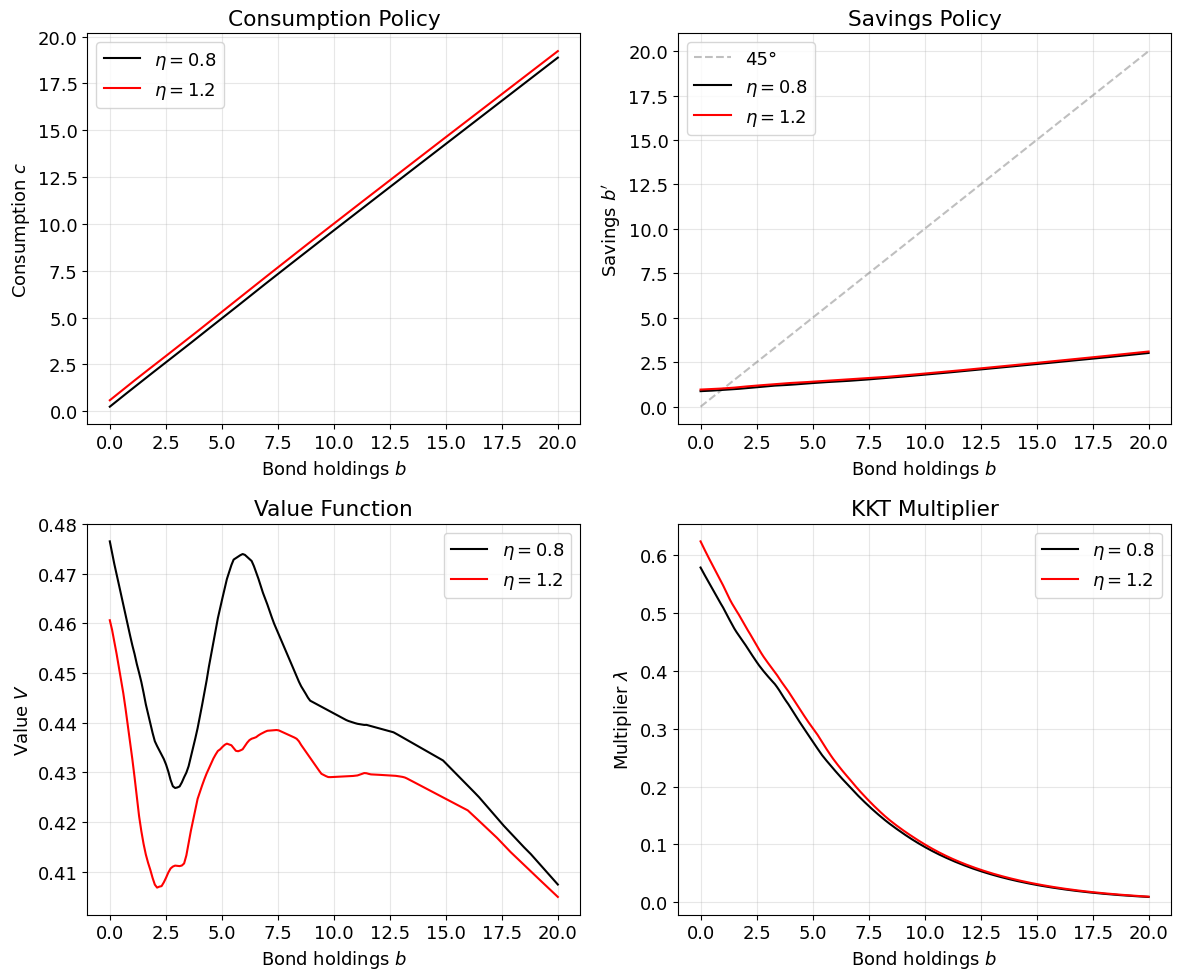

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = {0: 'k', 1: 'r'}
labels = {0: r'$\eta=0.8$', 1: r'$\eta=1.2$'}

# Consumption policy
for ei in range(nEta):
    axes[0, 0].plot(a_plot, results_eta[ei]['c'], colors[ei], label=labels[ei])
axes[0, 0].set_xlabel('Bond holdings $b$')
axes[0, 0].set_ylabel('Consumption $c$')
axes[0, 0].set_title('Consumption Policy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Savings policy with 45-degree line
axes[0, 1].plot(a_plot, a_plot, 'gray', linestyle='--', alpha=0.5, label='45°')
for ei in range(nEta):
    axes[0, 1].plot(a_plot, results_eta[ei]['b_prime'], colors[ei], label=labels[ei])
axes[0, 1].set_xlabel('Bond holdings $b$')
axes[0, 1].set_ylabel("Savings $b'$")
axes[0, 1].set_title('Savings Policy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Value function
for ei in range(nEta):
    axes[1, 0].plot(a_plot, results_eta[ei]['V'], colors[ei], label=labels[ei])
axes[1, 0].set_xlabel('Bond holdings $b$')
axes[1, 0].set_ylabel('Value $V$')
axes[1, 0].set_title('Value Function')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# KKT multiplier
for ei in range(nEta):
    axes[1, 1].plot(a_plot, results_eta[ei]['lambd'], colors[ei], label=labels[ei])
axes[1, 1].set_xlabel('Bond holdings $b$')
axes[1, 1].set_ylabel('Multiplier $\\lambda$')
axes[1, 1].set_title('KKT Multiplier')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Bond Prices and Wealth Distribution

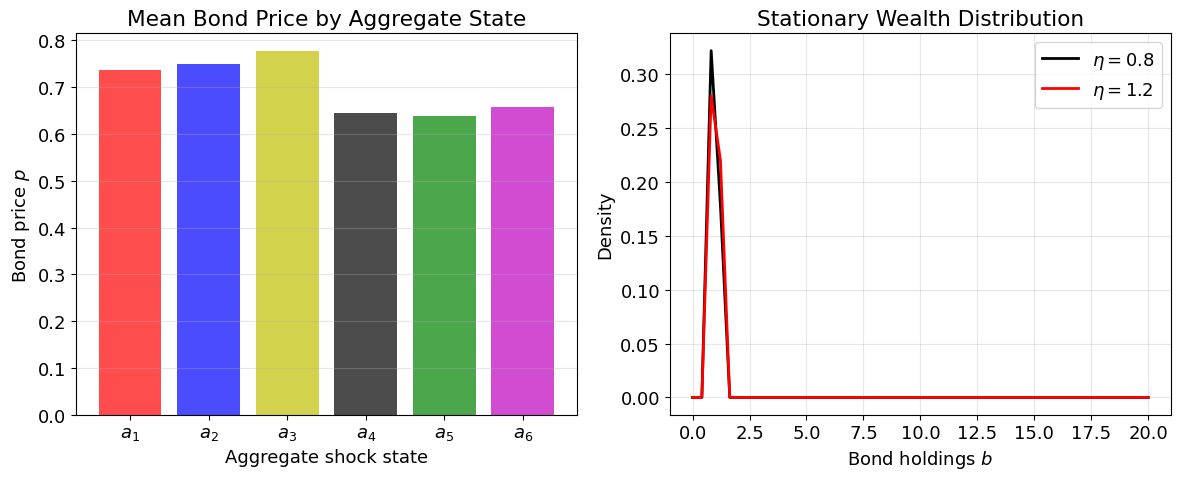

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bond price by aggregate state
cols = ['r', 'b', 'y', 'k', 'g', 'm']
prices_by_state = []
for i in range(nZ):
    # Get aggregate states with z_idx == i from the last simulation
    Xagg_evol_np = Xagg_evol.numpy() if hasattr(Xagg_evol, 'numpy') else Xagg_evol
    mask = Xagg_evol_np[:, 0] == i
    if mask.any():
        p_i = net_price(tf.constant(Xagg_evol_np[mask], dtype=tf.float32)).numpy()
        prices_by_state.append(np.mean(p_i))
    else:
        prices_by_state.append(np.nan)

ax1.bar(range(nZ), prices_by_state, color=[cols[i] for i in range(nZ)], alpha=0.7)
ax1.set_xlabel('Aggregate shock state')
ax1.set_ylabel('Bond price $p$')
ax1.set_title('Mean Bond Price by Aggregate State')
ax1.set_xticks(range(nZ))
ax1.set_xticklabels([f'$a_{i+1}$' for i in range(nZ)])
ax1.grid(True, alpha=0.3, axis='y')

# Wealth distribution (last histogram from training)
h_last = Xagg_0[-1, 3:]  # histogram from last aggregate state
agrid_np = agrid.numpy()
ax2.plot(agrid_np, h_last[:nA], 'k-', linewidth=2, label=r'$\eta=0.8$')
ax2.plot(agrid_np, h_last[nA:2*nA], 'r-', linewidth=2, label=r'$\eta=1.2$')
ax2.set_xlabel('Bond holdings $b$')
ax2.set_ylabel('Density')
ax2.set_title('Stationary Wealth Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Accuracy Assessment

We evaluate the per-equation residuals on the last batch of training data and plot Euler LHS vs RHS.

In [18]:
# ============================================================
# Evaluate residuals on last training batch
# ============================================================
# Get the last batch data
eval_data = create_training_data(len_episodes, num_id_per_shock, 
                                  tf.constant(Xagg_0, dtype=tf.float32), net_pol)
X_eval = eval_data[0][:batch_size*4]
Xaggnext_eval = [d[:batch_size*4] for d in eval_data[1:7]]

_, c_eval, releue_eval, relbee_eval, _, lambd_eval, _, mcerr_eval, KKTerr_eval = cost(
    net_pol, net_price, X_eval,
    Xaggnext_eval[0], Xaggnext_eval[1], Xaggnext_eval[2],
    Xaggnext_eval[3], Xaggnext_eval[4], Xaggnext_eval[5]
)

print("Per-equation residuals (absolute values):")
print(f"{'Equation':<20} {'Mean |.|':>12} {'Max |.|':>12}")
print("-" * 46)
print(f"{'Euler (EE)':<20} {np.mean(np.abs(releue_eval.numpy())):>12.2e} {np.max(np.abs(releue_eval.numpy())):>12.2e}")
print(f"{'Bellman (BE)':<20} {np.mean(np.abs(relbee_eval.numpy())):>12.2e} {np.max(np.abs(relbee_eval.numpy())):>12.2e}")
print(f"{'Market clearing':<20} {np.mean(np.abs(mcerr_eval.numpy()/nZ)):>12.2e} {np.max(np.abs(mcerr_eval.numpy()/nZ)):>12.2e}")
print(f"{'KKT':<20} {np.mean(np.abs(KKTerr_eval.numpy())):>12.2e} {np.max(np.abs(KKTerr_eval.numpy())):>12.2e}")

Per-equation residuals (absolute values):
Equation                 Mean |.|      Max |.|
----------------------------------------------
Euler (EE)               7.83e-01     2.04e+00
Bellman (BE)             5.46e-02     2.48e-01
Market clearing          1.43e-02     3.09e-02
KKT                      2.15e-01     6.53e-01


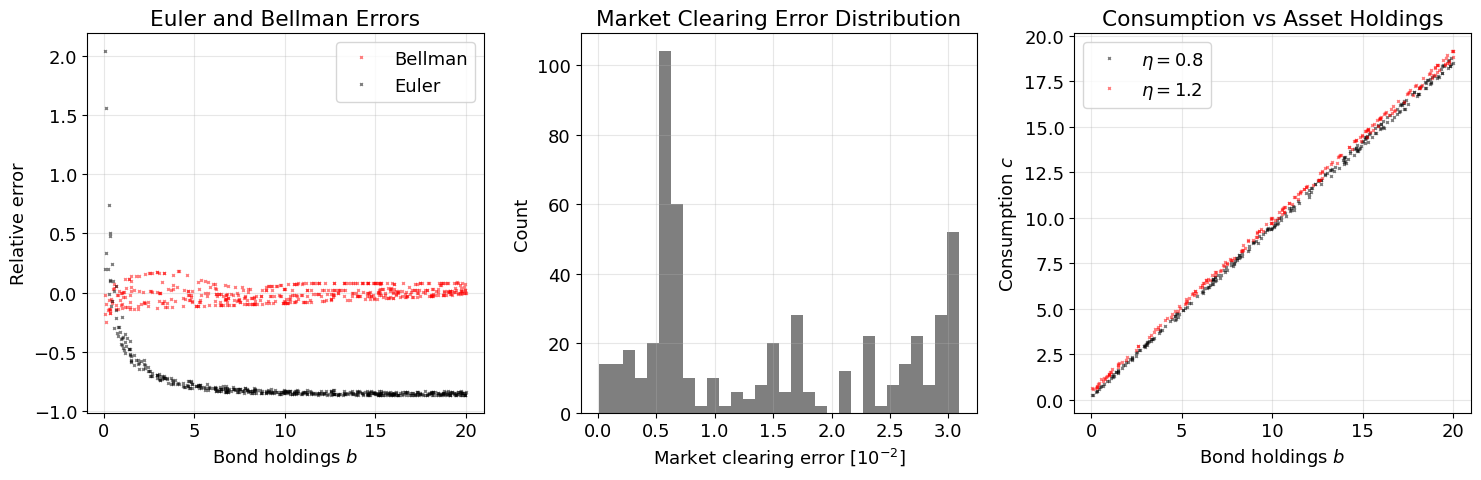

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

X_eval_np = X_eval.numpy()
mask_low = X_eval_np[:, 0] == 0
mask_high = X_eval_np[:, 0] == 1

# Euler and Bellman errors vs asset holdings
axes[0].plot(X_eval_np[:, 1], relbee_eval.numpy(), 'rx', markersize=2, alpha=0.5, label='Bellman')
axes[0].plot(X_eval_np[:, 1], releue_eval.numpy(), 'kx', markersize=2, alpha=0.5, label='Euler')
axes[0].set_xlabel('Bond holdings $b$')
axes[0].set_ylabel('Relative error')
axes[0].set_title('Euler and Bellman Errors')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Market clearing error histogram
axes[1].hist(np.abs(mcerr_eval.numpy().flatten() / nZ) * 100, bins=30, color='k', alpha=0.5)
axes[1].set_xlabel(r'Market clearing error [$10^{-2}$]')
axes[1].set_ylabel('Count')
axes[1].set_title('Market Clearing Error Distribution')
axes[1].grid(True, alpha=0.3)

# Consumption by eta
if mask_low.any():
    axes[2].plot(X_eval_np[mask_low, 1], c_eval.numpy()[mask_low], 'kx', 
                markersize=2, alpha=0.5, label=r'$\eta=0.8$')
if mask_high.any():
    axes[2].plot(X_eval_np[mask_high, 1], c_eval.numpy()[mask_high], 'rx',
                markersize=2, alpha=0.5, label=r'$\eta=1.2$')
axes[2].set_xlabel('Bond holdings $b$')
axes[2].set_ylabel('Consumption $c$')
axes[2].set_title('Consumption vs Asset Holdings')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

We solved a **Bewley endowment economy** with a **continuum of agents** using Deep Equilibrium Nets:

1. **Young's histogram method** provides a finite-dimensional, differentiable encoding of the wealth distribution
2. **Two neural networks** (policy + price) are trained jointly by minimizing equilibrium residuals
3. The **histogram co-evolves** with the network during training, converging to the ergodic distribution
4. **No separate forecasting rule** is needed — the price network conditions directly on the full histogram

### Key architectural choices
- Input dimension scales as $O(N_b)$ — the histogram resolution is a tunable parameter
- Softplus output activations ensure positivity of all policy variables
- Episode-based training with histogram carry-over ensures the network trains on equilibrium-consistent distributions

> **Note:** The checked-in notebook is configured in a smoke-style mode (128 hidden nodes, 100 episodes, $N_b = 50$) so the full pipeline is readable during class. A fuller classroom run increases to 500 episodes, while the production configuration in the paper uses 500 hidden nodes, 65,000 episodes, and $N_b = 100$.

### References
- Azinovic, M., Gaegauf, L., & Scheidegger, S. (2022). Deep equilibrium nets. *International Economic Review*, 63(4), 1471–1525.
- Young, E.R. (2010). Solving the incomplete markets model with aggregate uncertainty using the Krusell–Smith algorithm and non-stochastic simulations. *J. Econ. Dynamics & Control*, 34(1), 36–41.
- Krusell, P., & Smith, A.A. (1998). Income and wealth heterogeneity in the macroeconomy. *J. Political Economy*, 106(5), 867–896.